In [8]:
import pytensor
import numpy as np
import pandas as pd
import pymc as pm
import arviz as az
import xarray as xr
import sys
import matplotlib.pyplot as plt
import multiprocessing
import statsmodels.api as sm

In [2]:
np.random.seed(1)

#### Hierarchical (Multilevel) Models

In [16]:
# Defining the population.

n_classes = 8
students_per_class = 30

population_mean = 75
between_class_sd = 8
within_class_sd = 10

print("Number of classes: ", n_classes)
print("Students per class: ", students_per_class)

Number of classes:  8
Students per class:  30


In [17]:
# Simulating the true class means.

class_means = np.random.normal(loc=population_mean, scale=between_class_sd, size=n_classes)

print("True class means: ", np.round(class_means, 2))

# Simulating student scores.

scores = []
classes = []

for i in range(n_classes):

    class_scores = np.random.normal(loc=class_means[i], scale=within_class_sd, size=students_per_class)

    scores.extend(class_scores)
    classes.extend([i + 1] * students_per_class)

# Creating a DataFrame.

data = pd.DataFrame({
    "Class": classes,
    "Score": scores
})

print("First five observations:\n", data.head())

# Computing class summaries.

summary = data.groupby("Class")["Score"].agg(
    ["mean", "std", "count"]
)

print("Class summaries: ", summary)

True class means:  [80.09 86.27 87.97 68.55 72.99 78.06 72.69 71.87]
First five observations:
    Class      Score
0      1  86.932681
1      1  76.558567
2      1  62.213538
3      1  83.711140
4      1  75.847739
Class summaries:              mean        std  count
Class                             
1      79.702805  13.336760     30
2      87.991154   9.605002     30
3      87.533675   9.947845     30
4      68.744996   9.253417     30
5      71.927060  11.088373     30
6      77.781020   9.260274     30
7      71.346262  11.210028     30
8      72.236274   9.580724     30


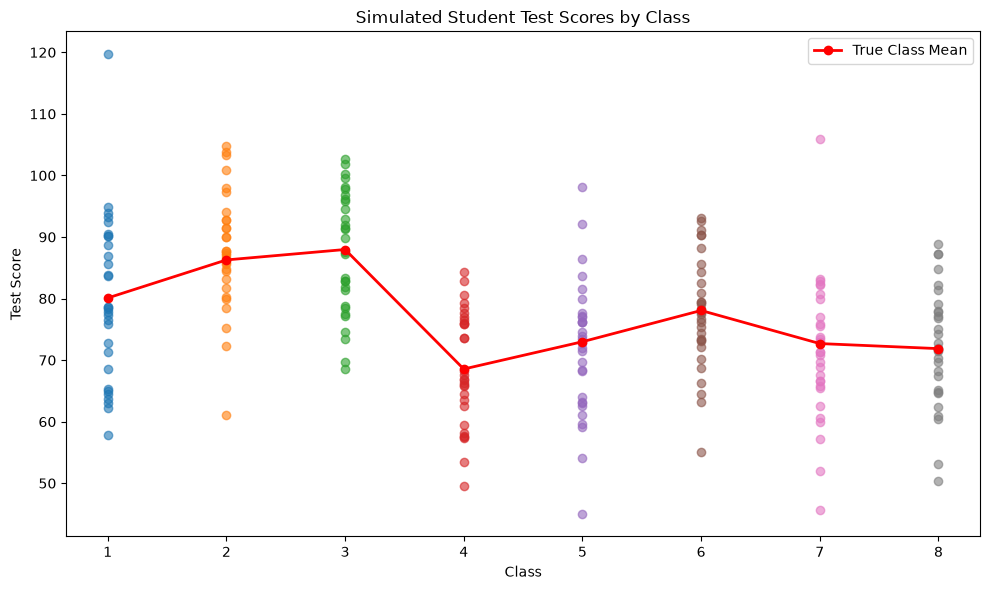

In [18]:
# Visualizing the simulated scores.

plt.figure(figsize=(10, 6))

for i in range(n_classes):

    class_scores = data[data["Class"] == i + 1]["Score"]

    plt.scatter(
        np.repeat(i + 1, len(class_scores)),
        class_scores,
        alpha=0.6
    )

plt.plot(
    np.arange(1, n_classes + 1),
    class_means,
    color="red",
    linewidth=2,
    marker="o",
    label="True Class Mean"
)

plt.title("Simulated Student Test Scores by Class")
plt.xlabel("Class")
plt.ylabel("Test Score")

plt.legend()

plt.tight_layout()

plt.show()

In [19]:
# Defining the population.

n_classes = 8
students_per_class = 30

population_mean = 75
between_class_sd = 8
within_class_sd = 10

# Simulating the true class means.

true_class_means = np.random.normal(loc=population_mean, scale=between_class_sd, size=n_classes)

# Simulating student scores.

scores = []
classes = []

for i in range(n_classes):

    class_scores = np.random.normal(loc=true_class_means[i], scale=within_class_sd, size=students_per_class)

    scores.extend(class_scores)
    classes.extend([i + 1] * students_per_class)

data = pd.DataFrame({
    "Class": classes,
    "Score": scores
})

In [20]:
# Computing observed class means.

observed_means = data.groupby("Class")["Score"].mean().values

# Computing the overall (pooled) mean.

overall_mean = data["Score"].mean()

print("Overall mean: ", round(overall_mean, 2))

# Computing the shrinkage weight.

tau2 = between_class_sd ** 2
sigma2 = within_class_sd ** 2
n = students_per_class

weight = tau2 / (tau2 + sigma2 / n)

print("Shrinkage weight:", round(weight, 3))

# Computing hierarchical estimates.

hierarchical_means = (weight * observed_means + (1 - weight) * overall_mean)

# Displaying results.

results = pd.DataFrame({

    "True Mean": np.round(true_class_means, 2),
    "Observed Mean": np.round(observed_means, 2),
    "Hierarchical Mean": np.round(hierarchical_means, 2)

})

print("\nEstimated Class Means:\n", results)

Overall mean:  71.72
Shrinkage weight: 0.95

Estimated Class Means:
    True Mean  Observed Mean  Hierarchical Mean
0      68.14          67.69              67.89
1      67.53          69.73              69.83
2      79.34          82.01              81.50
3      59.33          58.25              58.92
4      80.42          82.14              81.62
5      66.15          67.90              68.09
6      72.13          70.07              70.15
7      79.04          75.95              75.74


#### Pooled, Unpooled, and Hierarchical Estimates Graphically

In [21]:
# Defining the population.

n_classes = 8
students_per_class = 30

population_mean = 75
between_class_sd = 8
within_class_sd = 10

# Simulating the true class means.

true_class_means = np.random.normal(loc=population_mean, scale=between_class_sd, size=n_classes)

# Simulating student scores.

scores = []
classes = []

for i in range(n_classes):

    class_scores = np.random.normal(loc=true_class_means[i], scale=within_class_sd, size=students_per_class)

    scores.extend(class_scores)
    classes.extend([i + 1] * students_per_class)

data = pd.DataFrame({
    "Class": classes,
    "Score": scores
})

In [22]:
# Computing estimates.

observed_means = data.groupby("Class")["Score"].mean().values

pooled_mean = data["Score"].mean()

tau2 = between_class_sd ** 2
sigma2 = within_class_sd ** 2

weight = tau2 / (tau2 + sigma2 / students_per_class)

hierarchical_means = (weight * observed_means + (1 - weight) * pooled_mean)

# Displaying results.

results = pd.DataFrame({

    "True Mean": np.round(true_class_means, 2),
    "Unpooled Mean": np.round(observed_means, 2),
    "Hierarchical Mean": np.round(hierarchical_means, 2)

})

print(results)

print("\nPooled Mean: ", round(pooled_mean, 2))

   True Mean  Unpooled Mean  Hierarchical Mean
0      80.43          81.65              81.50
1      86.42          87.48              87.04
2      75.29          75.52              75.68
3      91.24          89.44              88.90
4      69.92          68.09              68.61
5      70.80          72.76              73.05
6      78.10          80.39              80.30
7      72.16          73.67              73.91

Pooled Mean:  78.62


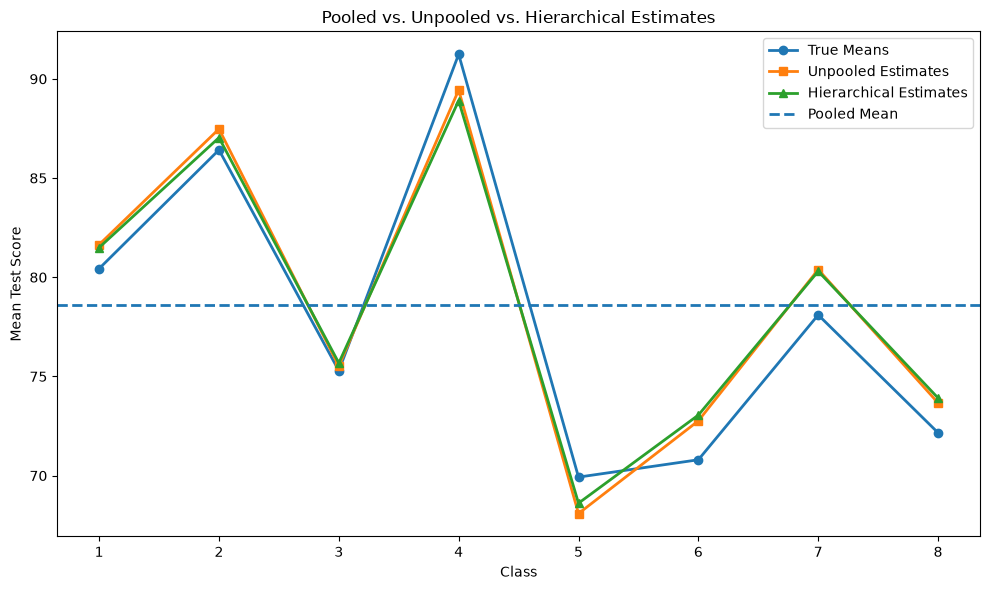

In [23]:
# Visualizing the comparison.

x = np.arange(1, n_classes + 1)

plt.figure(figsize=(10, 6))

plt.plot(
    x,
    true_class_means,
    marker="o",
    linewidth=2,
    label="True Means"
)

plt.plot(
    x,
    observed_means,
    marker="s",
    linewidth=2,
    label="Unpooled Estimates"
)

plt.plot(
    x,
    hierarchical_means,
    marker="^",
    linewidth=2,
    label="Hierarchical Estimates"
)

plt.axhline(
    pooled_mean,
    linestyle="--",
    linewidth=2,
    label="Pooled Mean"
)

plt.title("Pooled vs. Unpooled vs. Hierarchical Estimates")
plt.xlabel("Class")
plt.ylabel("Mean Test Score")


plt.legend()

plt.tight_layout()

plt.show()

#### Hierarchical Bayesian Model in PyMC

In [6]:
# Simulating hierarchical data.

n_classes = 8
students_per_class = 30

true_population_mean = 75
true_between_class_sd = 8
true_within_class_sd = 10

true_class_means = np.random.normal(loc=true_population_mean, scale=true_between_class_sd, size=n_classes)

scores = []
class_index = []

for i in range(n_classes):

    class_scores = np.random.normal(loc=true_class_means[i], scale=true_within_class_sd, size=students_per_class)

    scores.extend(class_scores)
    class_index.extend([i] * students_per_class)

scores = np.array(scores)
class_index = np.array(class_index)

print("Number of classes:", n_classes)
print("Students per class:", students_per_class)

Number of classes: 8
Students per class: 30


In [7]:
# Building the hierarchical Bayesian model.

with pm.Model() as hierarchical_model:

    # Hyperpriors.

    population_mean = pm.Normal(
        "population_mean",
        mu=70,
        sigma=20
    )

    between_class_sd = pm.HalfNormal(
        "between_class_sd",
        sigma=10
    )

    # Group-level priors.

    class_mean = pm.Normal(
        "class_mean",
        mu=population_mean,
        sigma=between_class_sd,
        shape=n_classes
    )

    # Observation-level parameter.

    within_class_sd = pm.HalfNormal(
        "within_class_sd",
        sigma=10
    )

    # Likelihood.

    score = pm.Normal(
        "score",
        mu=class_mean[class_index],
        sigma=within_class_sd,
        observed=scores
    )

    trace = pm.sample(
        draws=2000,
        tune=1000,
        random_seed=42,
        return_inferencedata=True
    )

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [population_mean, between_class_sd, class_mean, within_class_sd]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 30 seconds.


In [14]:
summary = az.summary(
    trace,
    hdi_prob=0.95
)

print("Posterior Summary")
print(summary)

Posterior Summary
                    mean     sd  hdi_2.5%  hdi_97.5%  mcse_mean  mcse_sd  \
population_mean   74.617  4.095    66.717     82.939      0.045    0.056   
class_mean[0]     86.046  1.698    82.660     89.280      0.016    0.022   
class_mean[1]     73.565  1.691    70.441     77.018      0.015    0.019   
class_mean[2]     71.424  1.724    68.009     74.775      0.015    0.021   
class_mean[3]     67.327  1.695    63.957     70.563      0.016    0.020   
class_mean[4]     82.624  1.662    79.315     85.756      0.015    0.020   
class_mean[5]     58.334  1.733    54.800     61.544      0.015    0.020   
class_mean[6]     89.328  1.708    85.984     92.690      0.015    0.020   
class_mean[7]     69.579  1.675    66.297     72.785      0.015    0.021   
between_class_sd  11.233  2.959     6.033     17.032      0.032    0.040   
within_class_sd    9.395  0.445     8.587     10.341      0.004    0.005   

                  ess_bulk  ess_tail  r_hat  
population_mean     874

#### Group-Level Variance and Individual Group Posteriors

In [15]:
# Posterior summary.

summary = pm.stats.summary(trace)

print("Posterior Summary: ", summary)

# Population-level parameters.

print("Population Mean: ",
      summary.loc["population_mean", "mean"])

print("Between-Class SD: ",
      summary.loc["between_class_sd", "mean"])

print("Within-Class SD: ",
      summary.loc["within_class_sd", "mean"])

Posterior Summary:                      mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  \
population_mean   74.617  4.095  67.148   82.544      0.045    0.056   
class_mean[0]     86.046  1.698  82.821   89.169      0.016    0.022   
class_mean[1]     73.565  1.691  70.424   76.690      0.015    0.019   
class_mean[2]     71.424  1.724  68.266   74.724      0.015    0.021   
class_mean[3]     67.327  1.695  64.149   70.525      0.016    0.020   
class_mean[4]     82.624  1.662  79.433   85.613      0.015    0.020   
class_mean[5]     58.334  1.733  55.093   61.560      0.015    0.020   
class_mean[6]     89.328  1.708  86.154   92.585      0.015    0.020   
class_mean[7]     69.579  1.675  66.325   72.541      0.015    0.021   
between_class_sd  11.233  2.959   6.150   16.669      0.032    0.040   
within_class_sd    9.395  0.445   8.610   10.290      0.004    0.005   

                  ess_bulk  ess_tail  r_hat  
population_mean     8743.0    5339.0    1.0  
class_mean[0]      1190

In [16]:
# Individual class means.

print("\nIndividual Class Means")

for i in range(8):

    value = float(summary.loc[f"class_mean[{i}]", "mean"])

    print(f"Class {i+1}: {value:.2f}")


Individual Class Means
Class 1: 86.05
Class 2: 73.56
Class 3: 71.42
Class 4: 67.33
Class 5: 82.62
Class 6: 58.33
Class 7: 89.33
Class 8: 69.58


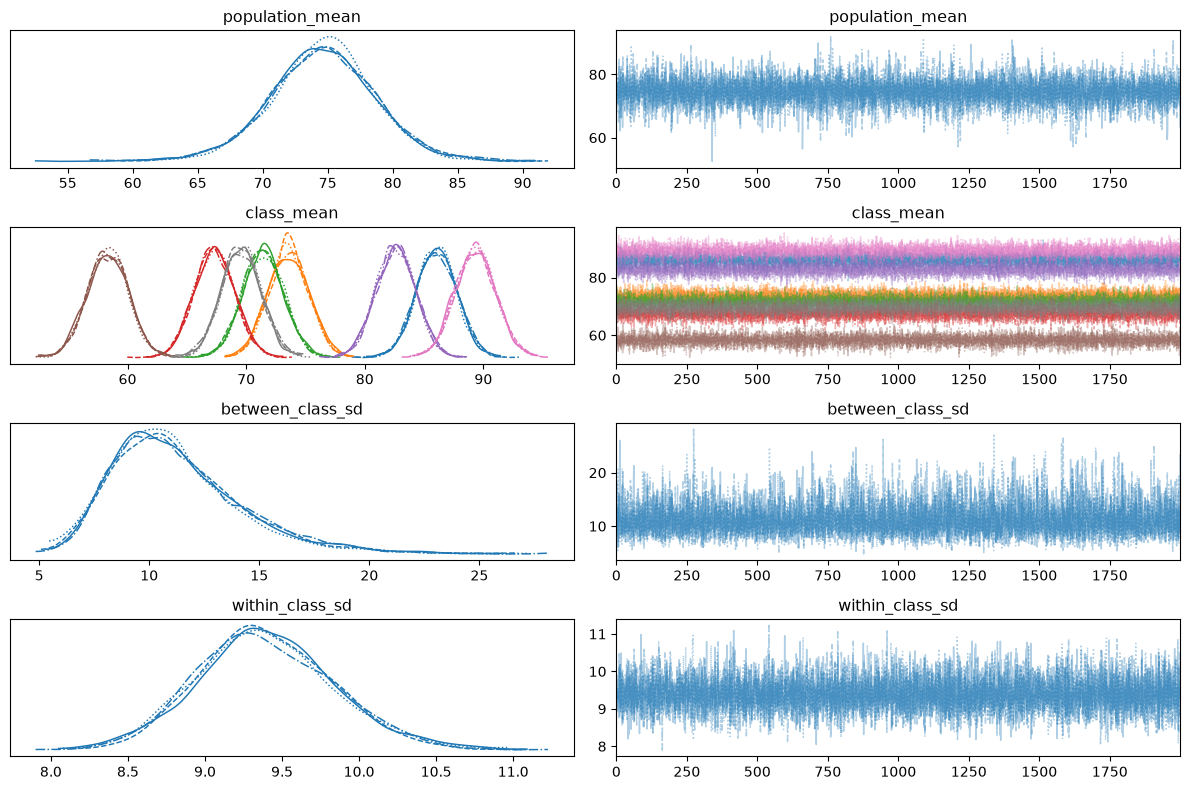

In [17]:
# Posterior distributions of class means.

az.plot_trace(trace)

plt.tight_layout()

plt.show()

#### Shrinkage Effect

In [23]:
# Computing posterior means of the class means.

hierarchical_means = (
    trace.posterior["class_mean"]
    .mean(dim=("chain", "draw"))
    .values
)

# Computing unpooled estimates.

unpooled_means = np.array([
    scores[class_index == i].mean()
    for i in range(n_classes)
])

# Computing the pooled mean.

pooled_mean = scores.mean()

print("True Class Means: ", np.round(true_class_means, 2))
print("Unpooled Means: ", np.round(unpooled_means, 2))
print("Hierarchical Means: ", np.round(hierarchical_means, 2))
print("Overall Mean: ", round(pooled_mean, 2))

True Class Means:  [87.99 70.11 70.77 66.42 81.92 56.59 88.96 68.91]
Unpooled Means:  [86.35 73.53 71.34 67.12 82.85 57.86 89.75 69.42]
Hierarchical Means:  [86.05 73.57 71.42 67.33 82.62 58.33 89.33 69.58]
Overall Mean:  74.78


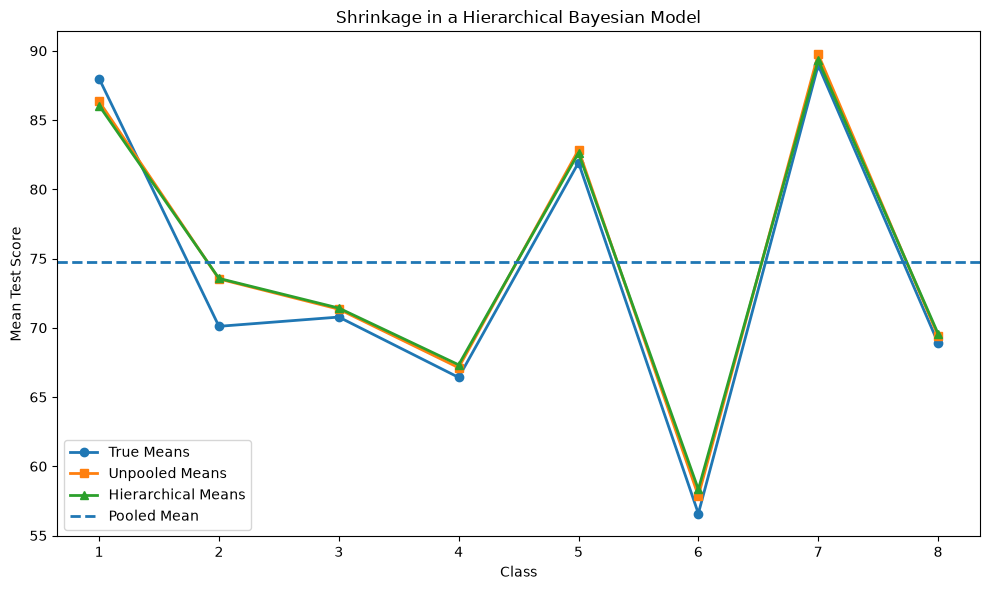

In [22]:
# Visualizing the comparison.

x = np.arange(1, n_classes + 1)

plt.figure(figsize=(10, 6))

plt.plot(
    x,
    true_class_means,
    marker="o",
    linewidth=2,
    label="True Means"
)

plt.plot(
    x,
    unpooled_means,
    marker="s",
    linewidth=2,
    label="Unpooled Means"
)

plt.plot(
    x,
    hierarchical_means,
    marker="^",
    linewidth=2,
    label="Hierarchical Means"
)

plt.axhline(
    pooled_mean,
    linestyle="--",
    linewidth=2,
    label="Pooled Mean"
)

plt.title("Shrinkage in a Hierarchical Bayesian Model")
plt.xlabel("Class")
plt.ylabel("Mean Test Score")

plt.legend()

plt.tight_layout()

plt.show()